# MGS-8 : Fitness Landscape Explorer -- voir la surface pour comprendre la recherche

[← MGS-7 TSP](MGS-7-TSP.ipynb) | [↑ Série MGS](../Part4-Metaheuristics/README.md)

**Pourquoi visualiser le paysage de fitness ?** Un algorithme de recherche explore une surface dont la *forme* dicte la difficulté : unimodale (un seul bassin, facile) ou multimodale (pièges locaux), vallée étroite (mal conditionnée) ou plateau (peu informatif). Tant que cette surface est invisible, le choix d'une métaheuristique relève du *doctrinal*. La visualiser rend le choix *éclairé*.

Ce notebook **ressuscite fidèlement** le *Landscape Explorer* original écrit par **jsboige** en Gtk# (`LandscapeExplorerSampleController.cs`, branche `Metaheuristics` de [MyIntelligenceAgency/GeneticSharp](https://github.com/giacomelli/GeneticSharp/pull/87) @ `d05826fd`). La bibliothèque de rendu a été récupérée **byte-exact** (les quatre cartes d'altitude originales + `ImageHeightMapFunction` + `DirectBitmap`) et le contrôleur Gtk# (lié à une UI qu'on ne peut pas porter tel quel) a été réincarné en `LandscapeRenderer`/`LandscapeHeatmap` dont **chaque formule de couleur et de marqueur est extraite verbatim** du contrôleur. Le rendu est **graphique** (`image/png`), pas ASCII.

Les **trois modes** du `LandscapeExplorer` original sont tous exercés ici :

| Mode (`enum LandscapeMode`) | Source du paysage | Rendu dans ce notebook |
|------------------------------|-------------------|------------------------|
| **`KnownFunction`** | une fonction analytique de `KnownFunctions` (Sphere, Rastrigin…) | heatmap graphique + trajectoire du GA superposée |
| **`KnownHeightMap`** | l'une des **4 cartes d'altitude originales** de jsboige | les 4 cartes rendues en heatmaps d'élévation |
| **`CustomImage`** | **n'importe quelle image** lue comme champ d'altitude | une image bimodale synthétique → paysage à 2 optima |

> **AUTHORSHIP (HARD).** Les fonctions et la math de rendu ne sont **jamais réimplémentées**. Chaque pixel d'une heatmap `KnownFunction` appelle la vraie `IFitness.Evaluate` du fork ; les cartes d'altitude sont les **PNG originaux** de jsboige (mêmes octets, embarqués comme ressources) ; le ramp de couleur HSV, les marqueurs d'extrema (min blanc / max noir) et le marqueur de population (diamant 5×5, individus `BlueViolet` / meilleur `Aqua`) sont **verbatim** du contrôleur. On *visualise autour* de la bibliothèque, on ne la duplique pas.

> **Pas de package de traçé.** Le rendu passe par `System.Drawing` (la `DirectBitmap` récupérée) exporté en PNG puis affiché en `<img src=\"data:image/png;base64,…\">` — ce qui évite la résolution `#r \"nuget:\"` (qui reste bloquée sous papermill sur cet environnement).


## Câblage : MetaGeneticSharp (fork) + bibliothèque Landscape

On charge les DLLs du fork construites localement, **toutes depuis le répertoire de sortie de `MetaGeneticSharp.Extensions`** : grâce à `CopyLocalLockFileAssemblies`, ce dossier est *self-contained* (il embarque `System.Drawing.Common.dll` ET `SkiaSharp.dll` + son binaire natif `runtimes/<rid>/native/libSkiaSharp.dll`). `Extensions` porte à la fois `KnownFunctions` (les fonctions de benchmark), les types Landscape (`LandscapeRenderer`, `LandscapeMaps`, `KnownHeightMap`, `ImageHeightMapFunction`), le pont `KnownFunctionLandscape` qui relie les deux, et le backend **`SkiaLandscapeRenderer`** (rendu PNG sans GDI+, cf section *Rendu cross-platform*).

> **Prérequis build.** `dotnet build c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/MetaGeneticSharp.Extensions.csproj -c Debug` (submodule épinglé sur le fork `7d1575c`).


In [1]:
// Fork DLLs loaded from the self-contained Extensions output (one-stop dir: it also ships
// System.Drawing.Common.dll AND SkiaSharp.dll, needed at runtime by the graphic landscape types).
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Infrastructure.Framework.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Infrastructure.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Extensions.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/System.Drawing.Common.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/SkiaSharp.dll"

using MetaGeneticSharp;                                 // LandscapeRenderer, LandscapeMaps, KnownHeightMap, KnownFunctions, SkiaLandscapeRenderer
using GeneticSharp;                                     // GA engine, selection/crossover/mutation
using GeneticSharp.Extensions.Mathematic.Functions;     // ImageHeightMapFunction (verbatim)
using GeneticSharp.Infrastructure.Framework.Images;     // DirectBitmap (verbatim)
using System.Drawing;                                   // Color, Bitmap
using System.Runtime.InteropServices;                   // NativeLibrary, RuntimeInformation

// .NET Interactive quirk: a #r to the managed SkiaSharp.dll does NOT wire up SkiaSharp's
// runtimes/<rid>/native/ probing, so the first Skia call would P/Invoke a native lib that was
// never loaded (BadImageFormatException 0x8007000B). We preload the arch-matching native binary
// from the self-contained output once, up front. Required because LandscapeHeatmap.ToPng() now
// encodes via SkiaSharp (cross-platform, no GDI+ encoder) on the fork @ 7d1575c.
string rid = RuntimeInformation.ProcessArchitecture == Architecture.Arm64 ? "win-arm64"
           : RuntimeInformation.ProcessArchitecture == Architecture.X86   ? "win-x86"
           : "win-x64";
NativeLibrary.Load($"c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/runtimes/{rid}/native/libSkiaSharp.dll");

Console.WriteLine("Wiring OK : MetaGeneticSharp + GeneticSharp + Extensions (KnownFunctions + Landscape + SkiaLandscapeRenderer).");
Console.WriteLine($"  KnownFunction   : {typeof(SphereFitness).Name}");
Console.WriteLine($"  Landscape types : {typeof(LandscapeRenderer).Name}, {typeof(LandscapeHeatmap).Name}, {typeof(LandscapeMaps).Name}");
Console.WriteLine($"  Cross-platform  : {typeof(SkiaLandscapeRenderer).Name} (SkiaSharp, native rid={rid})");
Console.WriteLine($"  HeightMaps      : {string.Join(", ", Enum.GetNames(typeof(KnownHeightMap)))}");


The below script needs to be able to find the current output cell; this is an easy method to get it.

Wiring OK : MetaGeneticSharp + GeneticSharp + Extensions (KnownFunctions + Landscape + SkiaLandscapeRenderer).


  KnownFunction   : SphereFitness


  Landscape types : LandscapeRenderer, LandscapeHeatmap, LandscapeMaps


  Cross-platform  : SkiaLandscapeRenderer (SkiaSharp, native rid=win-x64)


  HeightMaps      : EverestMount, NepalBhoutan, TibetanPlateau, World


## Terrain commun : chromosome continu + affichage des heatmaps

`DoubleArrayChromosome` stocke des gènes `double` nus (cf. MGS-6) ; son `CreateNew()` randomise dans les bornes — diversité initiale indispensable pour que le GA explore. Les paysages `KnownFunction` sont évalués en construisant un tel chromosome par pixel, puis en appelant la vraie `IFitness.Evaluate`.

`ShowHeatmap` exporte la `DirectBitmap` rendue en PNG (`LandscapeHeatmap.ToPng()`) et l'affiche **inline** via une balise `<img>` base64 — média graphique, sans dépendance de traçé.


In [2]:
// DoubleArrayChromosome: minimal continuous chromosome (bare double genes), with per-gene
// bounds so CreateNew() randomizes the initial population -- else the GA could not explore.
public class DoubleArrayChromosome : ChromosomeBase
{
    private readonly double _min;
    private readonly double _max;
    public DoubleArrayChromosome(double[] values, double min, double max) : base(values.Length)
    {
        _min = min; _max = max;
        for (int i = 0; i < values.Length; i++) ReplaceGene(i, new Gene(values[i]));
    }
    public override IChromosome CreateNew()
    {
        var rand = RandomizationProvider.Current;
        var vals = new double[Length];
        for (int i = 0; i < Length; i++) vals[i] = rand.GetDouble(_min, _max);
        return new DoubleArrayChromosome(vals, _min, _max);
    }
    public override Gene GenerateGene(int geneIndex)
        => new Gene(RandomizationProvider.Current.GetDouble(_min, _max));
    public double[] GetDoubleValues() => GetGenes().Select(g => (double)g.Value).ToArray();
}

// Inline display: a heatmap PNG as a base64 data-URI <img> (image/png), rendered by the kernel.
// LandscapeHeatmap.ToPng() saves the DirectBitmap via System.Drawing -- no plotting package.
string HeatmapHtml(byte[] png, string caption, int displayWidth)
{
    string b64 = Convert.ToBase64String(png);
    return $"<figure style='margin:6px 0'>"
         + $"<img src='data:image/png;base64,{b64}' style='width:{displayWidth}px;image-rendering:pixelated;border:1px solid #ccc'/>"
         + $"<figcaption style='font:12px sans-serif;color:#555'>{caption}</figcaption></figure>";
}
void ShowHeatmap(LandscapeHeatmap hm, string caption, int displayWidth = 460)
    => display(HTML(HeatmapHtml(hm.ToPng(), caption, displayWidth)));

var probe = new DoubleArrayChromosome(new double[]{1.5, -2.0}, -5.12, 5.12);
Console.WriteLine($"DoubleArrayChromosome + ShowHeatmap prets. Probe 2D : ({string.Join(", ", probe.GetDoubleValues())})");

DoubleArrayChromosome + ShowHeatmap prets. Probe 2D : (1,5, -2)



warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



## Mode 1/3 — `KnownFunction` : un paysage analytique en heatmap graphique

On rend `SphereFitness` (unimodale, optimum à l'origine) sur ses bornes. Le pont **`KnownFunctionLandscape.RenderHeatmap(sphere)`** branche la **vraie** `IFitness` directement sur le renderer : il adapte chaque pixel vers le chromosome que la fitness lit et résout les bornes via `KnownFunctionsBounds` — aucun adaptateur câblé à la main. Chaque pixel appelle la **vraie** `SphereFitness.Evaluate` (composition, jamais de réimplémentation). Le ramp de couleur est verbatim : **rouge = fitness haute** (proche de l'optimum), **cyan = fitness basse** ; le maximum global est marqué **noir**, le minimum **blanc**.

> **Objectif vs fitness.** `KnownFunctions` *minimisent* ; GeneticSharp *maximise*. `Evaluate` renvoie donc l'objectif **négativé** : la fitness est maximale (rouge) au fond du bassin.


KnownFunction -- SphereFitness, bornes [-5,12, 5,12] (rouge = fitness haute ; optimum = pixel noir)
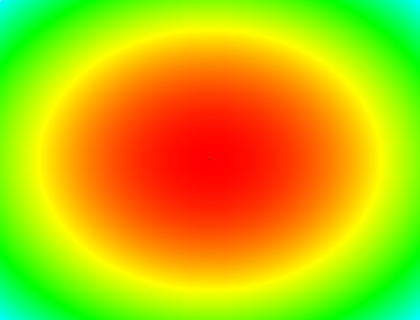

Sphere : fitness @ origine = -0 (max attendu), @ coin = -52,429.


In [3]:
// MODE KnownFunction : real SphereFitness rendered as a GRAPHIC heatmap.
// Pont H1 (KnownFunctionLandscape) : il branche une IFitness benchmark directement sur le
// renderer -- chaque pixel est adapte vers le chromosome que la fitness lit, et les bornes
// sont resolues via KnownFunctionsBounds. Plus aucun adaptateur cable a la main.
IFitness sphere = new SphereFitness();
var (slo, shi) = KnownFunctionsBounds.For(typeof(SphereFitness));

using (var sphereHm = KnownFunctionLandscape.RenderHeatmap(sphere, width: 420, height: 320))
    ShowHeatmap(sphereHm, $"KnownFunction -- SphereFitness, bornes [{slo}, {shi}] (rouge = fitness haute ; optimum = pixel noir)");

// La fitness reste la vraie SphereFitness (composition, jamais reimplementee) :
Func<double[], double> sphereField = c => sphere.Evaluate(new DoubleArrayChromosome(c, slo, shi));
Console.WriteLine($"Sphere : fitness @ origine = {sphereField(new[]{0.0, 0.0}):G5} (max attendu), @ coin = {sphereField(new[]{shi, shi}):G5}.");

## Feature (d) : trajectoire du GA superposée

On lance un vrai `MetaGeneticAlgorithm` (30 générations) puis on superpose la **population finale** (`BlueViolet`) et le **meilleur individu** (`Aqua`) sur la heatmap, via `LandscapeHeatmap.Plot` — les couleurs de marqueur sont verbatim du contrôleur. On voit le GA converger vers le bassin rouge.

> **Gotcha order-preserving (réutilisé de MGS-7).** `MetaPopulation` n'appelle jamais `Generation.End()` ; `CurrentGeneration.BestChromosome` est donc **null**. On dérive le meilleur via `Chromosomes.OrderByDescending(Fitness).First()`.


Feature (d) -- population finale (BlueViolet) + meilleur (Aqua) @ (0,119, 0,0297)
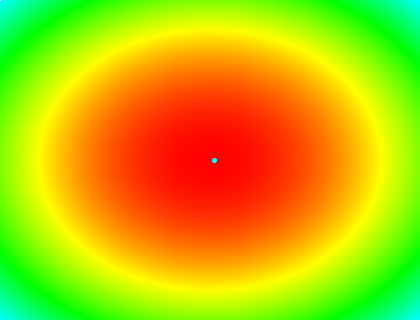

GA Sphere : 40 individus, meilleur = (0,1185, 0,02969), fitness = -0,014928 (optimum @ origine).


In [4]:
// Feature (d): run a real GA, then Plot the final population (BlueViolet) + best (Aqua).
(List<double[]> finalPop, double[] best) RunGa(IFitness f, Type ft, int generations = 30)
{
    var (lo, hi) = KnownFunctionsBounds.For(ft);
    var adam = new DoubleArrayChromosome(Enumerable.Repeat(0.5 * (lo + hi), 2).ToArray(), lo, hi);
    var pop = new MetaPopulation(40, 40, adam);
    var ga = new MetaGeneticAlgorithm(pop, f, new EliteSelection(),
        new UniformCrossover(0.5f), new UniformMutation(true), new DefaultMetaHeuristic());
    ga.Termination = new GenerationNumberTermination(generations);
    ga.Start();
    // MetaPopulation is order-preserving: CurrentGeneration.BestChromosome is null here.
    var chroms = ga.Population.CurrentGeneration.Chromosomes;
    var finalPop = chroms.Select(c => ((DoubleArrayChromosome)c).GetDoubleValues()).ToList();
    var best = ((DoubleArrayChromosome)chroms.OrderByDescending(c => c.Fitness).First()).GetDoubleValues();
    return (finalPop, best);
}

var (sPop, sBest) = RunGa(sphere, typeof(SphereFitness));
using (var trajHm = LandscapeRenderer.RenderHeatmap(sphereField, (slo, shi), (slo, shi), width: 420, height: 320))
{
    trajHm.Plot(sPop, sBest);
    ShowHeatmap(trajHm, $"Feature (d) -- population finale (BlueViolet) + meilleur (Aqua) @ ({sBest[0]:G3}, {sBest[1]:G3})");
}
Console.WriteLine($"GA Sphere : {sPop.Count} individus, meilleur = ({sBest[0]:G4}, {sBest[1]:G4}), fitness = {sphereField(sBest):G5} (optimum @ origine).");

## Rendu cross-platform — `SkiaLandscapeRenderer` (sans GDI+)

Le rendu graphique original passe par `System.Drawing` (GDI+), **Windows-only** sur .NET 6+ : sous un kernel Linux, `Bitmap.Save(..., ImageFormat.Png)` et la toile `DirectBitmap` lèvent. C'est exactement le déménagement que jsboige avait recommandé dans `ImageExtensions.cs:46` (@ `d05826fd`) : *« a move to SharpImage or other libs is recommended rather than the compatibility System.Drawing »*.

Le backend **`SkiaLandscapeRenderer`** (additif — les originaux byte-exact `DirectBitmap` / `ImageExtensions` sont **intacts**) produit **la même heatmap PNG graphique** sans aucune dépendance GDI+ :

- `RenderHeatmapPng(fonction, bornes…)` — échantillonne la fonction directement sur une toile SkiaSharp et encode le PNG : **zéro GDI+**, le chemin tourne de bout en bout sur Linux (le mode `KnownFunction` ne charge aucune image).
- `LandscapeHeatmap.ToPng()` (utilisé partout ci-dessus) **délègue désormais** son encodage à SkiaSharp : l'export PNG ne requiert plus l'encodeur GDI+.

Le ramp de couleur et le marqueur 5×5 en losange restent **verbatim** (`LandscapeRenderer.GetColor`) — seule la plomberie de la toile est portée. *Honnêteté : les modes adossés à une image (`KnownHeightMap` / `CustomImage`) chargent encore leur niveau de gris via le `ImageExtensions` GDI+ verbatim ; migrer ce décodage à SkiaSharp est le déménagement « SharpImage » complet, suivi en backlog.*


SkiaLandscapeRenderer.RenderHeatmapPng -> PNG 32673 octets, magic 89504E47 (PNG).


SkiaLandscapeRenderer (sans GDI+) -- meme SphereFitness, memes marqueurs ; losanges = population (BlueViolet), best (Aqua)
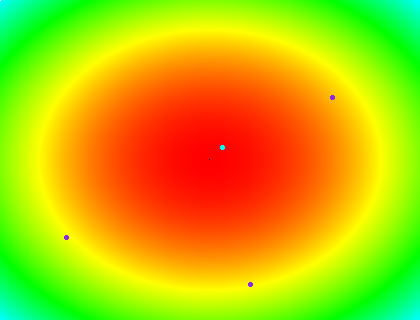


warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



In [5]:
// Cross-platform render of the SAME function landscape, fully GDI-free (no DirectBitmap, no GDI+
// encoder) -- this exact call runs unchanged on a Linux kernel. Reuses the real sphereField from
// Mode 1 (composition, never reimplemented) and the verbatim color ramp / diamond markers.
var skiaPop = new[] { new[]{ 3.0, -2.0 }, new[]{ -3.5, 2.5 }, new[]{ 1.0, 4.0 } };
var skiaBest = new[]{ 0.3, -0.4 };

byte[] skiaPng = SkiaLandscapeRenderer.RenderHeatmapPng(
    sphereField, (slo, shi), (slo, shi), width: 420, height: 320,
    population: skiaPop, best: skiaBest);

Console.WriteLine($"SkiaLandscapeRenderer.RenderHeatmapPng -> PNG {skiaPng.Length} octets, magic {skiaPng[0]:X2}{skiaPng[1]:X2}{skiaPng[2]:X2}{skiaPng[3]:X2} (PNG).");
display(HTML(HeatmapHtml(skiaPng, "SkiaLandscapeRenderer (sans GDI+) -- meme SphereFitness, memes marqueurs ; losanges = population (BlueViolet), best (Aqua)", 460)));

## Mode 2/3 — `KnownHeightMap` : les 4 cartes d'altitude originales de jsboige

Les quatre cartes (`EverestMount`, `NepalBhoutan`, `TibetanPlateau`, `World`) sont les **PNG originaux** authored par jsboige pour l'échantillon `LandscapeExplorer`, récupérés **byte-exact** (`sha256 == blob git source @ d05826fd`) et embarqués comme ressources. `LandscapeMaps.CreateFunction(map)` construit la **verbatim** `ImageHeightMapFunction` (luminosité du pixel = altitude, avec interpolation inverse-distance) ; `RenderHeatmap` colore l'élévation : **rouge = sommets**, **cyan = plaines/océans**.


KnownHeightMap.EverestMount -- carte originale 2560x1383 px (rouge = altitude haute)
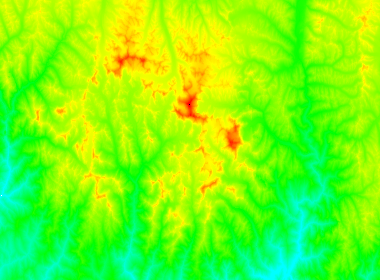

KnownHeightMap.NepalBhoutan -- carte originale 2560x1383 px (rouge = altitude haute)
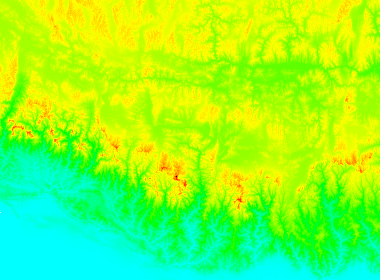

KnownHeightMap.TibetanPlateau -- carte originale 2560x1383 px (rouge = altitude haute)
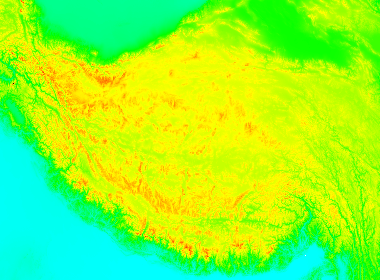

KnownHeightMap.World -- carte originale 2560x1440 px (rouge = altitude haute)
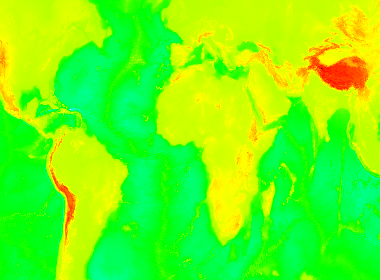

Les 4 cartes d'altitude originales de jsboige, rendues en heatmaps graphiques (image/png).


In [6]:
// MODE KnownHeightMap : the four ORIGINAL maps rendered as graphic elevation heatmaps.
foreach (KnownHeightMap map in new[]
    { KnownHeightMap.EverestMount, KnownHeightMap.NepalBhoutan, KnownHeightMap.TibetanPlateau, KnownHeightMap.World })
{
    using ImageHeightMapFunction fn = LandscapeMaps.CreateFunction(map);
    var ranges = fn.Ranges(2);
    using var hm = LandscapeRenderer.RenderHeatmap(fn, width: 380, height: 280);
    ShowHeatmap(hm, $"KnownHeightMap.{map} -- carte originale {(int)ranges[0].max + 1}x{(int)ranges[1].max + 1} px (rouge = altitude haute)", 420);
}
Console.WriteLine("Les 4 cartes d'altitude originales de jsboige, rendues en heatmaps graphiques (image/png).");

## Mode 3/3 — `CustomImage` : n'importe quelle image devient un paysage

Le troisième mode du `LandscapeExplorer` accepte une **image arbitraire** comme champ d'altitude. Comme les deux autres modes, il a désormais un **point d'entrée de première classe** dans `LandscapeMaps`, symétrique de `CreateFunction(KnownHeightMap)` (Mode 2) et de `KnownFunctionLandscape.RenderHeatmap` (Mode 1) :

- **`LandscapeMaps.CreateFunctionFromImage(image, name?)`** — enveloppe un bitmap **en mémoire**. Le setter `TargetImage` en fait une copie niveaux-de-gris, donc l'appelant **garde la propriété** de son image et la libère lui-même.
- **`LandscapeMaps.CreateFunctionFromFile(path, name?)`** — charge un fichier image, le copie en niveaux de gris, puis **libère la source chargée** (aucune fuite) ; nom par défaut = nom du fichier.

On synthétise ici une image bimodale (deux bosses claires) **en mémoire** (a) qu'on enveloppe via `CreateFunctionFromImage`, puis (b) on illustre littéralement « dépose un fichier, obtiens un paysage » en l'enregistrant sur disque et en la rechargeant via `CreateFunctionFromFile` — le fichier est ensuite supprimé sans erreur, preuve que le helper a bien libéré la source. Les deux bosses apparaissent comme deux optima (rouge).

> **Strate wrapper.** `LandscapeMaps` est l'orchestration écrite par le portage ; la lecture pixel→altitude reste la **verbatim** `ImageHeightMapFunction` de jsboige (récupérée byte-exact de GeneticSharp @ `d05826fd`, [PR #87](https://github.com/giacomelli/GeneticSharp/pull/87)). Ces deux helpers sont un **wrapper additif** par-dessus — aucune carte remplacée, aucune fonction réimplémentée. Fork lib : `cb96ec7c`.

CustomImage (a) -- CreateFunctionFromImage : image bimodale en memoire lue comme paysage (2 pics = 2 optima)
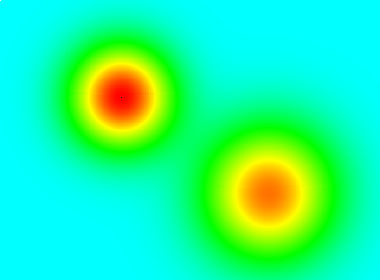

CustomImage (b) -- CreateFunctionFromFile : nom par defaut = 'mgs7_custom_be613008794247c3b520f7f0b6a19e75', meme paysage rendu depuis le disque
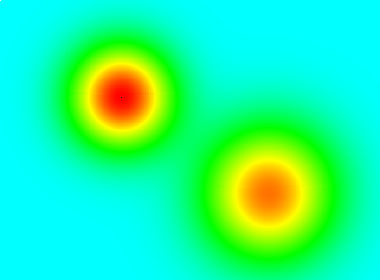

Mode CustomImage : image -> CreateFunctionFromImage (memoire) et CreateFunctionFromFile (disque) ; fichier 'mgs7_custom_be613008794247c3b520f7f0b6a19e75.png' libere apres rendu.



warning CS1701: En supposant que la référence d'assembly 'System.Private.Windows.Core, Version=9.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' utilisée par 'System.Drawing.Common' correspond à l'identité 'System.Private.Windows.Core, Version=10.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' de 'System.Private.Windows.Core', il se peut que vous deviez fournir une stratégie runtime

warning CS1701: En supposant que la référence d'assembly 'System.Private.Windows.Core, Version=9.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' utilisée par 'System.Drawing.Common' correspond à l'identité 'System.Private.Windows.Core, Version=10.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' de 'System.Private.Windows.Core', il se peut que vous deviez fournir une stratégie runtime

warning CS1701: En supposant que la référence d'assembly 'System.Private.Windows.Core, Version=9.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' utilisée par 'System.Drawing.Common

In [7]:
// MODE CustomImage : a bimodal grayscale image read as a landscape, now via the FIRST-CLASS
// helpers LandscapeMaps.CreateFunctionFromImage / CreateFunctionFromFile (H2) -- symmetric with
// CreateFunction(KnownHeightMap) (Mode 2) and KnownFunctionLandscape (Mode 1). The wrapper just
// hands the bitmap to the VERBATIM ImageHeightMapFunction; the pixel->elevation read is jsboige's.
using System.IO;

var custom = new Bitmap(220, 160);
for (int y = 0; y < custom.Height; y++)
    for (int x = 0; x < custom.Width; x++)
    {
        double b1 = Math.Exp(-((x - 70) * (x - 70) + (y - 55) * (y - 55)) / 900.0);
        double b2 = Math.Exp(-((x - 155) * (x - 155) + (y - 110) * (y - 110)) / 1500.0);
        int v = (int)(255 * Math.Min(1.0, b1 + 0.85 * b2));
        custom.SetPixel(x, y, Color.FromArgb(v, v, v));
    }

// (a) In-memory bitmap -> first-class CreateFunctionFromImage. The setter copies to grayscale,
//     so we keep ownership of `custom` and dispose it ourselves below (no leak, no double-free).
using (ImageHeightMapFunction customFn = LandscapeMaps.CreateFunctionFromImage(custom, "CustomBimodal"))
using (var customHm = LandscapeRenderer.RenderHeatmap(customFn, width: 380, height: 280))
    ShowHeatmap(customHm, "CustomImage (a) -- CreateFunctionFromImage : image bimodale en memoire lue comme paysage (2 pics = 2 optima)", 420);

// (b) The literal "drop a file, get a landscape" story: save to disk, reload via
//     CreateFunctionFromFile (default name = file stem), render, then delete -- the file is
//     fully released because the helper disposes the loaded source after the grayscale copy.
string tmpPng = Path.Combine(Path.GetTempPath(), $"mgs7_custom_{Guid.NewGuid():N}.png");
custom.Save(tmpPng, System.Drawing.Imaging.ImageFormat.Png);
custom.Dispose();   // caller image no longer needed; the file is now the source

using (ImageHeightMapFunction fileFn = LandscapeMaps.CreateFunctionFromFile(tmpPng))
using (var fileHm = LandscapeRenderer.RenderHeatmap(fileFn, width: 380, height: 280))
    ShowHeatmap(fileHm, $"CustomImage (b) -- CreateFunctionFromFile : nom par defaut = '{Path.GetFileNameWithoutExtension(tmpPng)}', meme paysage rendu depuis le disque", 420);

File.Delete(tmpPng);   // succeeds: CreateFunctionFromFile released the loaded image (no leak)
Console.WriteLine($"Mode CustomImage : image -> CreateFunctionFromImage (memoire) et CreateFunctionFromFile (disque) ; fichier '{Path.GetFileName(tmpPng)}' libere apres rendu.");

## Interpolation pixel->altitude : IDW (original) vs bilineaire (M1)

Comment l'altitude est-elle lue **entre** deux pixels ? La fonction verbatim de jsboige, `ImageHeightMapFunction`, interpole les 4 coins d'une cellule par **ponderation inverse-distance (IDW)** -- mais seulement *strictement a l'interieur* d'une cellule (garde `if (x > xDraw && y > yDraw)`, ligne 49 @ `d05826fd`). Sur une **ligne de grille** (x ou y entier), la garde est fausse : elle retombe sur le pixel plancher le plus proche. Le champ d'altitude **fait donc un escalier** le long de chaque ligne de grille (discontinu).

`BilinearHeightMapFunction` (M1) est un **sibling additif** : meme champ niveaux-de-gris, memes ranges, meme contrat (`Ranges`/`Fitness`/`Dispose`, meme garde hors-bornes) -- mais interpolation **bilineaire vraie**, *continue partout*, qui se reduit au melange lineaire 1-D sur une ligne de grille. L'original est **inchange** et reste le defaut ; on **ajoute** un choix, expose symetriquement par `LandscapeMaps.CreateBilinearFunctionFromImage` (jumeau de `CreateFunctionFromImage`).

> **Co-evolution.** L'IDW de jsboige (@ `d05826fd`) est preserve byte-exact ; la bilineaire est purement additive (fork lib : `ed013e1`). On compare les deux sur la **meme image** -- aucune carte remplacee, aucune fonction reimplementee.

IDW (ImageHeightMapFunction verbatim jsboige) : interpolation seulement A L'INTERIEUR des cellules, escalier sur les lignes de grille
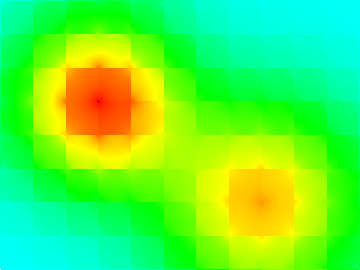

Bilineaire (BilinearHeightMapFunction, M1) : continue partout, y compris sur les lignes de grille
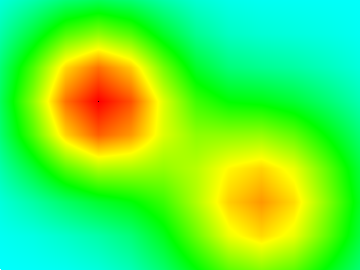

Sur la ligne de grille y=3, point x=3.5 :


  pixels voisins  : R(3,3)=255  R(4,3)=228


  IDW (original)  : 255  (= plancher R(3,3), escalier)


  Bilineaire (M1) : 241,5  (= moyenne 1-D (255+228)/2)


  delta           : 13,5 niveaux de gris



warning CS1701: En supposant que la référence d'assembly 'System.Private.Windows.Core, Version=9.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' utilisée par 'System.Drawing.Common' correspond à l'identité 'System.Private.Windows.Core, Version=10.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' de 'System.Private.Windows.Core', il se peut que vous deviez fournir une stratégie runtime

warning CS1701: En supposant que la référence d'assembly 'System.Private.Windows.Core, Version=9.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' utilisée par 'System.Drawing.Common' correspond à l'identité 'System.Private.Windows.Core, Version=10.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' de 'System.Private.Windows.Core', il se peut que vous deviez fournir une stratégie runtime

warning CS1701: En supposant que la référence d'assembly 'System.Private.Windows.Core, Version=9.0.0.0, Culture=neutral, PublicKeyToken=b77a5c561934e089' utilisée par 'System.Drawing.Common

In [8]:
// IDW (ImageHeightMapFunction verbatim) vs bilineaire (BilinearHeightMapFunction, M1) sur la MEME
// image. On part d'une PETITE image (12x9) pour rendre le delta VISIBLE : chaque pixel couvre
// beaucoup de pixels canvas, donc l'IDW de jsboige laisse apparaitre ses cellules (interpolation
// intra-cellule + escalier sur les lignes de grille), la bilineaire lisse continument.
var small = new Bitmap(12, 9);
for (int y = 0; y < small.Height; y++)
    for (int x = 0; x < small.Width; x++)
    {
        double b1 = Math.Exp(-((x - 3) * (x - 3) + (y - 3) * (y - 3)) / 6.0);
        double b2 = Math.Exp(-((x - 8) * (x - 8) + (y - 6) * (y - 6)) / 9.0);
        int v = (int)(255 * Math.Min(1.0, b1 + 0.8 * b2));
        small.SetPixel(x, y, Color.FromArgb(v, v, v));
    }

// Deux fonctions d'altitude sur la MEME image : IDW verbatim (Mode 3) vs bilineaire additive (M1).
using (ImageHeightMapFunction idwFn  = LandscapeMaps.CreateFunctionFromImage(small, "IDW"))
using (BilinearHeightMapFunction biFn = LandscapeMaps.CreateBilinearFunctionFromImage(small, "Bilineaire"))
{
    using (var idwHm = LandscapeRenderer.RenderHeatmap(idwFn, width: 360, height: 270))
        ShowHeatmap(idwHm, "IDW (ImageHeightMapFunction verbatim jsboige) : interpolation seulement A L'INTERIEUR des cellules, escalier sur les lignes de grille", 400);
    using (var biHm = LandscapeRenderer.RenderHeatmap(biFn, width: 360, height: 270))
        ShowHeatmap(biHm, "Bilineaire (BilinearHeightMapFunction, M1) : continue partout, y compris sur les lignes de grille", 400);

    // Preuve numerique du delta sur une ligne de grille (y entier, x fractionnaire) :
    // l'IDW retombe sur le pixel plancher, la bilineaire fait la moyenne 1-D des extremites.
    double g0 = biFn.Function(new[] { 3.0, 3.0 });   // pixel exact -> les deux schemas coincident
    double g1 = biFn.Function(new[] { 4.0, 3.0 });
    double idwOnLine = idwFn.Function(new[] { 3.5, 3.0 });
    double biOnLine  = biFn.Function(new[] { 3.5, 3.0 });
    Console.WriteLine("Sur la ligne de grille y=3, point x=3.5 :");
    Console.WriteLine($"  pixels voisins  : R(3,3)={g0}  R(4,3)={g1}");
    Console.WriteLine($"  IDW (original)  : {idwOnLine}  (= plancher R(3,3), escalier)");
    Console.WriteLine($"  Bilineaire (M1) : {biOnLine}  (= moyenne 1-D ({g0}+{g1})/2)");
    Console.WriteLine($"  delta           : {Math.Abs(biOnLine - idwOnLine):F1} niveaux de gris");
}
small.Dispose();

## Bonus : le biais de centre rendu VISIBLE (composition, pas réécriture)

Presque toutes les `KnownFunctions` ont leur optimum **au centre** des bornes symétriques. Un GA dont les opérateurs « recentrent » la population bénéficie alors d'un avantage *fortuit*. Pour tester si la recherche est **authentique**, on **déplace** l'optimum avec un wrapper `ShiftedFitness` qui translate les coordonnées avant d'appeler la **vraie** `SphereFitness` (composition autour de la fonction de jsboige, pas une réimplémentation). Si le GA suit l'optimum déplacé (`Aqua` proche de (2,2)), la recherche est dirigée par la fitness, pas par un biais de centre.


Bonus -- Sphere translatee, optimum @ (2,2) ; le GA y converge (2,05, 1,78) => recherche authentique
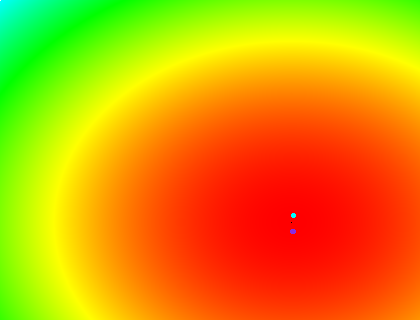

GA Sphere translatee : meilleur @ (2,048, 1,778) -- proche de (2,2), pas du centre.


In [9]:
// ShiftedFitness: translate coords before calling the REAL SphereFitness (composition).
public class ShiftedFitness : IFitness
{
    private readonly IFitness _inner;
    private readonly double[] _offset;
    public ShiftedFitness(IFitness inner, double[] offset) { _inner = inner; _offset = offset; }
    public double Evaluate(IChromosome chromosome)
    {
        var vals = ((DoubleArrayChromosome)chromosome).GetDoubleValues();
        var shifted = new double[vals.Length];
        for (int i = 0; i < vals.Length; i++) shifted[i] = vals[i] - _offset[i];
        return _inner.Evaluate(new DoubleArrayChromosome(shifted, -1e9, 1e9));
    }
}

var shifted = new ShiftedFitness(new SphereFitness(), new[] { 2.0, 2.0 });
Func<double[], double> shiftedField = c => shifted.Evaluate(new DoubleArrayChromosome(c, slo, shi));
var (shPop, shBest) = RunGa(shifted, typeof(SphereFitness));
using (var shHm = LandscapeRenderer.RenderHeatmap(shiftedField, (slo, shi), (slo, shi), width: 420, height: 320))
{
    shHm.Plot(shPop, shBest);
    ShowHeatmap(shHm, $"Bonus -- Sphere translatee, optimum @ (2,2) ; le GA y converge ({shBest[0]:G3}, {shBest[1]:G3}) => recherche authentique");
}
Console.WriteLine($"GA Sphere translatee : meilleur @ ({shBest[0]:G4}, {shBest[1]:G4}) -- proche de (2,2), pas du centre.");

## Exercices

> **Convention** : cellules à compléter. Squelette fourni, à vous d'implémenter. Ne **pas** lever d'erreur — utiliser `// TODO` / `Console.WriteLine` / `return` selon le contexte. Conserver les commentaires `// Indice` / `// Etape N`. Les helpers `RenderHeatmap`, `ShowHeatmap`, `RunGa`, `sphere`, `slo`, `shi` sont déjà définis plus haut.


### Exercice 1 : une fonction multimodale en heatmap graphique

Rendez `RastriginFitness` ou `AckleyFitness` (multimodales) et repérez visuellement les **optima locaux** (les bandes/anneaux). *Indice* : le bassin global de Rastrigin est à l'origine, entouré d'une forêt régulière de minima locaux ; Ackley a un « cratère » central et des ondulations concentriques.


In [10]:
// Exercice 1 : heatmap graphique d'une fonction multimodale.
// TODO etudiant : rendre RastriginFitness (ou AckleyFitness) et reperer les optima locaux.
// Indice : le pont H1 KnownFunctionLandscape rend une IFitness benchmark directement,
//          bornes auto via KnownFunctionsBounds (plus besoin de cabler un adaptateur).
//   IFitness f = new RastriginFitness();
//   using var hm = KnownFunctionLandscape.RenderHeatmap(f);     // bornes auto
//   ShowHeatmap(hm, "Rastrigin -- foret de minima locaux");

Console.WriteLine("Exercice 1 a completer : heatmap graphique d'une fonction multimodale (Rastrigin / Ackley).");

Exercice 1 a completer : heatmap graphique d'une fonction multimodale (Rastrigin / Ackley).


### Exercice 2 : monter en dimension et interpréter la projection

Projetez `SphereFitness` en dimension 5 sur le plan (x0, x1) : pour chaque pixel, fixez x0/x1, **échantillonnez** les dims cachées 2..4 dans les bornes et gardez la fitness **MAX** (le « plafond » le long des dims cachées, fidèle au `GetFunctionValue` de jsboige). *Indice* : augmentez le nombre d'échantillons et observez si la tache dense s'accentue ou s'estompe.


In [11]:
// Exercice 2 : projeter Sphere n=5 sur le plan (x0,x1), heatmap graphique.
// TODO etudiant : echantillonner les dims cachees 2..4, garder la fitness MAX, rendre la heatmap.
// Indice :
//   double Field5(double[] c) {
//       var rng = RandomizationProvider.Current; double best = double.MinValue;
//       for (int s = 0; s < 12; s++) {                 // Etape 1 : plusieurs echantillons
//           var v = new double[5]; v[0] = c[0]; v[1] = c[1];
//           for (int d = 2; d < 5; d++) v[d] = rng.GetDouble(slo, shi);
//           best = Math.Max(best, sphere.Evaluate(new DoubleArrayChromosome(v, slo, shi)));
//       }
//       return best;                                   // Etape 2 : le "plafond" projete
//   }
//   using var hm = LandscapeRenderer.RenderHeatmap(Field5, (slo, shi), (slo, shi));
//   ShowHeatmap(hm, "Sphere n=5 -- projection max sur 3 dims cachees");

Console.WriteLine("Exercice 2 a completer : projection 2D de Sphere en dimension 5 (echantillonnage max).");

Exercice 2 a completer : projection 2D de Sphere en dimension 5 (echantillonnage max).


### Exercice 3 : trajectoire de WOA sur le paysage de Schwefel

Construisez WOA depuis des primitives (`WhaleOptimisationAlgorithm.Build()` avec un `GeometricConverter<double>` identité, cf. MGS-6), lancez-le sur `SchwefelFitness`, puis superposez la trajectoire (`hm.Plot`) à la heatmap de Schwefel. *Question* : WOA se piège-t-elle dans un optimum local déceptif, ou son contrôle-flux géométrique la fait-il diverger ? Confrontez au verdict du banc MGS-6.


In [12]:
// Exercice 3 : trajectoire de WOA sur la heatmap de Schwefel (cf MGS-6 : WOA y diverge).
// TODO etudiant : construire WOA (GeometricConverter<double> identite, cf MGS-6 BuildWOA),
// l'injecter comme metaheuristique dans une variante de RunGa sur SchwefelFitness, puis
// rendre la heatmap de Schwefel et y superposer la trajectoire avec hm.Plot(pop, best).
// Indice (WOA depuis primitives) :
//   var woa = new WhaleOptimisationAlgorithm { MaxGenerations = 30 };
//   woa.SetGeometricConverter(new GeometricConverter<double> {
//       GeneToDoubleConverter = (_, v) => v, DoubleToGeneConverter = (_, d) => d });
//   IMetaHeuristic meta = woa.Build();

Console.WriteLine("Exercice 3 a completer : trajectoire de WOA sur Schwefel (piege local ou divergence ?).");

Exercice 3 a completer : trajectoire de WOA sur Schwefel (piege local ou divergence ?).


### Exercice 4 : ou IDW et bilineaire divergent le plus

Les deux interpolations coincident aux noeuds entiers de la grille et divergent entre eux. **Objectif** : sur une ligne de scan horizontale (y entier fixe), echantillonner `x` finement et trouver le point ou l'ecart `|bilineaire - IDW|` est **maximal**.

- `# Indice` : construis les deux fonctions sur la meme image (`CreateFunctionFromImage` pour l'IDW, `CreateBilinearFunctionFromImage` pour la bilineaire).
- `# Indice` : balaye `x` de `0` a `W-1` par pas de `0.05` a `y` entier fixe, calcule l'ecart, garde le `x` du max.
- `# Etape` : l'ecart est nul aux entiers ; pour l'IDW qui fait l'escalier, il est generalement maximal **pres du milieu** d'une cellule. Verifie-le.

In [13]:
// Exercice 4 : trouver le x ou |bilineaire - IDW| est maximal sur une ligne de scan.
// A COMPLETER. Le notebook s'execute de bout en bout meme si l'exercice n'est pas fait.

// # Indice : reutilise une petite image (ex. celle de la section Interpolation) ou synthetise-en une.
// # Indice : construis idwFn = LandscapeMaps.CreateFunctionFromImage(img) et
//            biFn  = LandscapeMaps.CreateBilinearFunctionFromImage(img).
// # Etape : fixe y entier (ex. y = 3), balaye x de 0 a img.Width-1 par pas de 0.05,
//           calcule ecart = Math.Abs(biFn.Function(new[]{x,y}) - idwFn.Function(new[]{x,y})),
//           garde xMax = x du plus grand ecart, puis affiche (xMax, ecartMax).

// TODO etudiant : implementer le balayage et afficher (xMax, ecartMax).
Console.WriteLine("Exercice 4 a completer : balayer une ligne de scan et reporter le x du delta IDW/bilineaire maximal.");

Exercice 4 a completer : balayer une ligne de scan et reporter le x du delta IDW/bilineaire maximal.


## Conclusion : la surface rendue inspectable — en vrai graphique

Le Landscape Explorer fait pour l'**espace de recherche** ce que le banc MGS-6 fait pour l'**algorithme** : il rend le problème *visible*. Ici, fidèle à l'original de jsboige, le rendu est **graphique** (`image/png`) et les **trois modes** sont exercés : une fonction analytique (`KnownFunction`) avec la trajectoire du GA superposée, les **quatre cartes d'altitude originales** (`KnownHeightMap`), et une image arbitraire (`CustomImage`). Le bonus « shifted » démontre que la recherche du GA est **authentique** : déplacé hors du centre, l'optimum est suivi.

La discipline « components over metaphors » tient jusqu'au rendu : la math de couleur et de marqueur est **verbatim** du contrôleur Gtk# de jsboige, les cartes sont ses **PNG originaux** byte-exact, et les fonctions ne sont **jamais réimplémentées** — on visualise *autour* de la bibliothèque. Et le rendu lui-même est désormais **cross-platform** : `SkiaLandscapeRenderer` encode les mêmes PNG graphiques sans GDI+, réalisant le déménagement « SharpImage » que jsboige avait recommandé (`ImageExtensions.cs:46` @ `d05826fd`).

## Liens

- [MGS-1 Introduction](MGS-1-Introduction.ipynb) -- le moteur autonome `MetaGeneticAlgorithm`
- [MGS-2 Composition](MGS-2-Composition.ipynb) -- primitives `Match` et grammaire fluente
- [MGS-3 Eukaryote](MGS-3-Eukaryote.ipynb) -- sous-populations spécialisées
- [MGS-4 Islands](MGS-4-Islands.ipynb) -- modèle insulaire et migration
- [MGS-6 Benchmarks](MGS-6-Benchmarks.ipynb) -- banc comparatif (ce notebook en explique visuellement les verdicts)
- [MGS-7 TSP](MGS-7-TSP.ipynb) -- composition agnostique à la représentation
- [Point d'entrée Part 4](../Part4-Metaheuristics/README.md) -- positionnement MGS vs GeneticSharp/mealpy/HeuristicLab
- [Fork jsboige/MetaGeneticSharp](https://github.com/jsboige/MetaGeneticSharp) -- code source, bibliothèque Landscape récupérée (@ `d05826fd`), contrôleur Gtk# original
